# A06 Brain Tumor

|                |   |
:----------------|---|
| **Nombre**     |  Emilio Navarro |
| **Fecha**      | 23-03-2026  |
| **Expediente** |  757955 | 

## Carga de datos

In [121]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score

In [122]:
df = pd.read_csv("brain_tumor_dataset.csv")


In [123]:
df.head()


,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,1,73,Male,Malignant,5.375612,Temporal,Astrocytoma,III,Vision Issues,Seizures,Seizures,No,No,No,51.312579,0.111876,No,Positive,Yes
1,2,26,Male,Benign,4.847098,Parietal,Glioblastoma,II,Headache,Headache,Nausea,Yes,Yes,Yes,46.373273,2.165736,Yes,Positive,Yes
2,3,31,Male,Benign,5.588391,Parietal,Meningioma,I,Vision Issues,Headache,Seizures,No,No,No,47.072221,1.884228,No,Negative,No
3,4,29,Male,Malignant,1.436600,Temporal,Medulloblastoma,IV,Vision Issues,Seizures,Headache,Yes,No,Yes,51.853634,1.283342,Yes,Negative,No
4,5,54,Female,Benign,2.417506,Parietal,Glioblastoma,I,Headache,Headache,Seizures,No,No,Yes,54.708987,2.069477,No,Positive,Yes


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           20000 non-null  int64  
 1   Age                  20000 non-null  int64  
 2   Gender               20000 non-null  object 
 3   Tumor_Type           20000 non-null  object 
 4   Tumor_Size           20000 non-null  float64
 5   Location             20000 non-null  object 
 6   Histology            20000 non-null  object 
 7   Stage                20000 non-null  object 
 8   Symptom_1            20000 non-null  object 
 9   Symptom_2            20000 non-null  object 
 10  Symptom_3            20000 non-null  object 
 11  Radiation_Treatment  20000 non-null  object 
 12  Surgery_Performed    20000 non-null  object 
 13  Chemotherapy         20000 non-null  object 
 14  Survival_Rate        20000 non-null  float64
 15  Tumor_Growth_Rate    20000 non-null 

In [125]:
df.describe()

,Patient_ID,Age,Tumor_Size,Survival_Rate,Tumor_Growth_Rate
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,49.433700,5.236552,70.131699,1.547701
std,5773.647028,17.389296,2.754359,17.270834,0.835995
min,1.000000,20.000000,0.500410,40.002386,0.100017
25%,5000.750000,34.000000,2.836686,55.224439,0.830433
50%,10000.500000,49.000000,5.200675,70.305066,1.541821
75%,15000.250000,65.000000,7.624299,85.043395,2.262484
max,20000.000000,79.000000,9.999420,99.998125,2.999835


## Revisión de valores únicos por columna

In [126]:
for column in df.columns:
    print (f"{column}: {df[column].unique()} unique values")

Patient_ID: [    1     2     3 ... 19998 19999 20000] unique values
Age: [73 26 31 29 54 27 72 61 50 79 58 71 62 37 20 67 65 36 46 55 76 49 41 38
 63 44 56 70 42 64 48 52 78 23 39 33 32 34 30 25 75 43 47 28 60 66 35 57
 22 21 59 69 45 40 51 74 24 53 68 77] unique values
Gender: ['Male' 'Female'] unique values
Tumor_Type: ['Malignant' 'Benign'] unique values
Tumor_Size: [5.37561155 4.84709779 5.58839071 ... 3.61863429 8.5190863  9.71676844] unique values
Location: ['Temporal' 'Parietal' 'Frontal' 'Occipital'] unique values
Histology: ['Astrocytoma' 'Glioblastoma' 'Meningioma' 'Medulloblastoma'] unique values
Stage: ['III' 'II' 'I' 'IV'] unique values
Symptom_1: ['Vision Issues' 'Headache' 'Seizures' 'Nausea'] unique values
Symptom_2: ['Seizures' 'Headache' 'Vision Issues' 'Nausea'] unique values
Symptom_3: ['Seizures' 'Nausea' 'Headache' 'Vision Issues'] unique values
Radiation_Treatment: ['No' 'Yes'] unique values
Surgery_Performed: ['No' 'Yes'] unique values
Chemotherapy: ['No' 'Yes']

In [127]:
for column in df.columns:
    print (f"{column}: {df[column].nunique()} unique values")

Patient_ID: 20000 unique values
Age: 60 unique values
Gender: 2 unique values
Tumor_Type: 2 unique values
Tumor_Size: 20000 unique values
Location: 4 unique values
Histology: 4 unique values
Stage: 4 unique values
Symptom_1: 4 unique values
Symptom_2: 4 unique values
Symptom_3: 4 unique values
Radiation_Treatment: 2 unique values
Surgery_Performed: 2 unique values
Chemotherapy: 2 unique values
Survival_Rate: 20000 unique values
Tumor_Growth_Rate: 20000 unique values
Family_History: 2 unique values
MRI_Result: 2 unique values
Follow_Up_Required: 2 unique values


## Distribución de cada variable y sus respectivas graficas

In [128]:
df["Gender"].value_counts()
df["Gender"].value_counts(normalize=True)*100

Gender
Female    50.08
Male      49.92
Name: proportion, dtype: float64

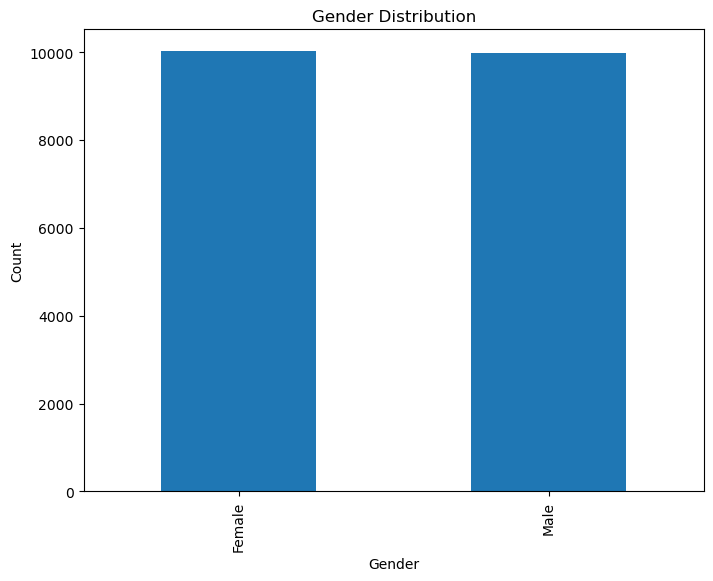

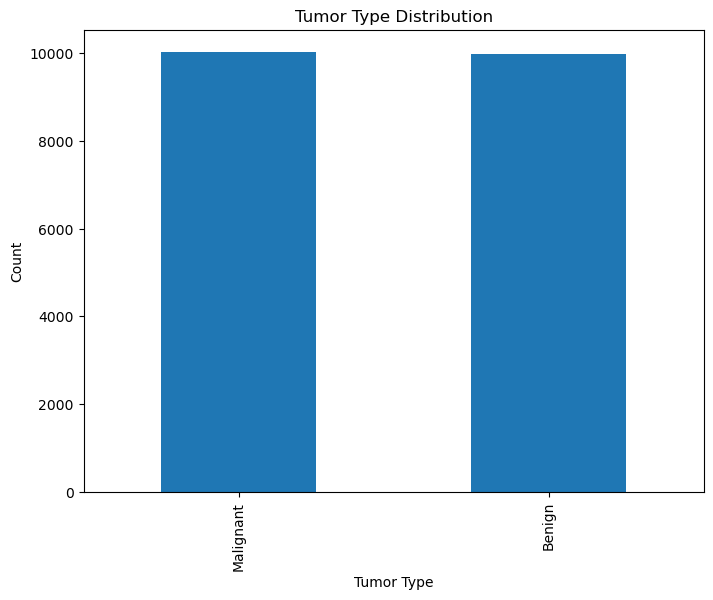

In [129]:
plt.figure(figsize=(8,6))
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.figure(figsize=(8,6))
df["Tumor_Type"].value_counts().plot(kind="bar")
plt.title("Tumor Type Distribution")
plt.xlabel("Tumor Type")
plt.ylabel("Count")
plt.show()

In [130]:
df['Tumor_Type'].value_counts()
df['Tumor_Type'].value_counts(normalize=True)*100

Tumor_Type
Malignant    50.15
Benign       49.85
Name: proportion, dtype: float64

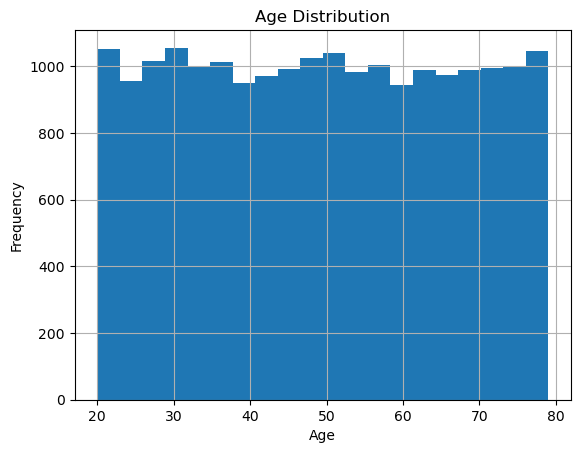

In [131]:
df["Age"].hist(bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

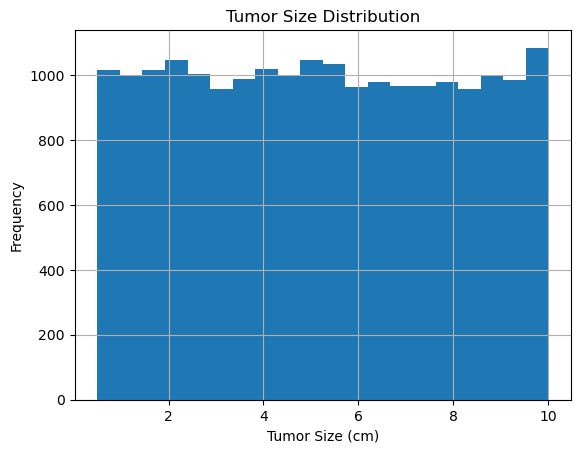

In [132]:
df["Tumor_Size"].hist(bins=20)
plt.title("Tumor Size Distribution")
plt.xlabel("Tumor Size (cm)")
plt.ylabel("Frequency")
plt.show()

In [133]:
df["Location"].value_counts()
df["Location"].value_counts(normalize=True)*100

Location
Temporal     25.590
Parietal     24.950
Occipital    24.835
Frontal      24.625
Name: proportion, dtype: float64

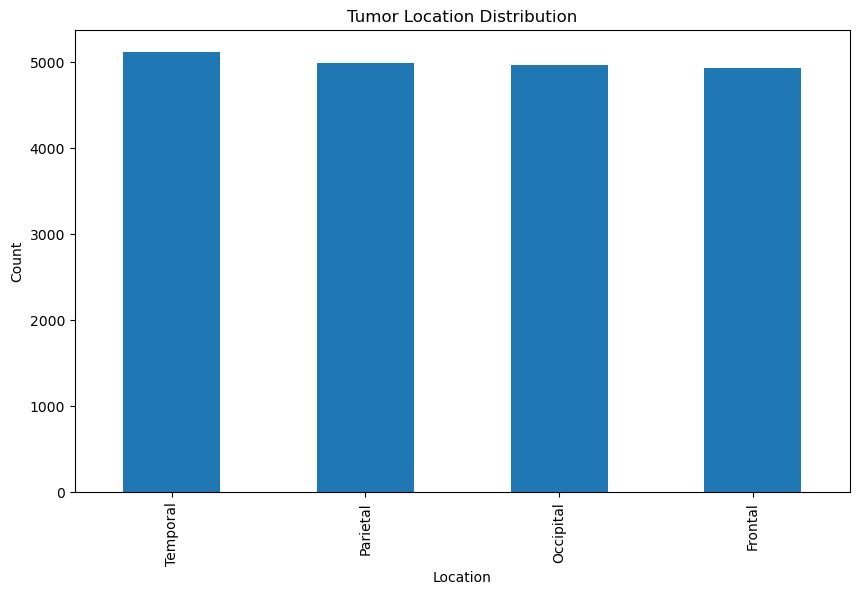

In [134]:
plt.figure(figsize=(10,6))
df["Location"].value_counts().plot(kind="bar")
plt.title("Tumor Location Distribution")
plt.xlabel("Location")
plt.ylabel("Count")
plt.show()

In [135]:
df["Histology"].value_counts()
df["Histology"].value_counts(normalize=True)*100

Histology
Glioblastoma       25.340
Meningioma         25.080
Medulloblastoma    24.895
Astrocytoma        24.685
Name: proportion, dtype: float64

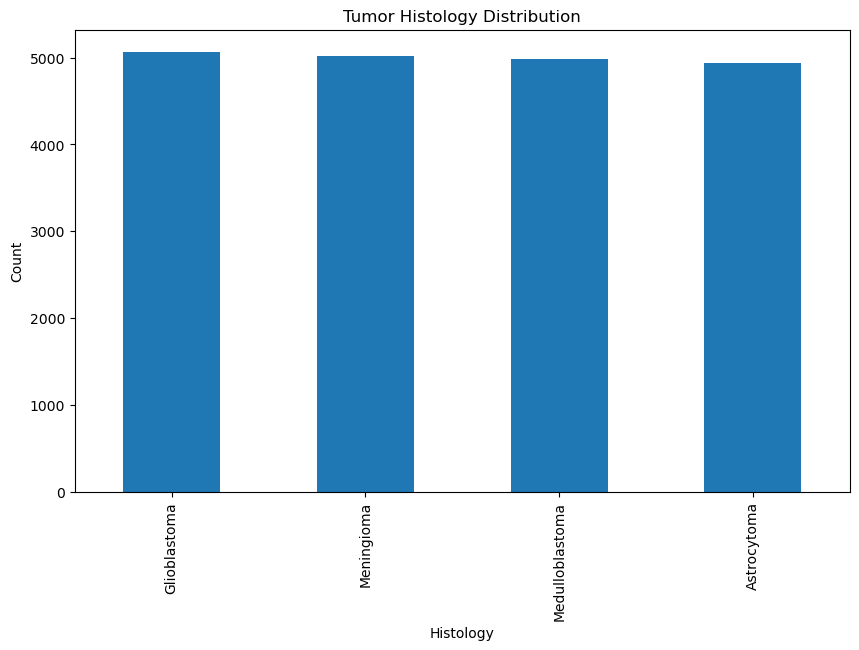

In [136]:
plt.figure(figsize=(10,6))
df["Histology"].value_counts().plot(kind="bar")
plt.title("Tumor Histology Distribution")
plt.xlabel("Histology")
plt.ylabel("Count")
plt.show()

In [137]:
df["Stage"].value_counts()
df["Stage"].value_counts(normalize=True)*100

Stage
II     25.465
I      24.930
IV     24.840
III    24.765
Name: proportion, dtype: float64

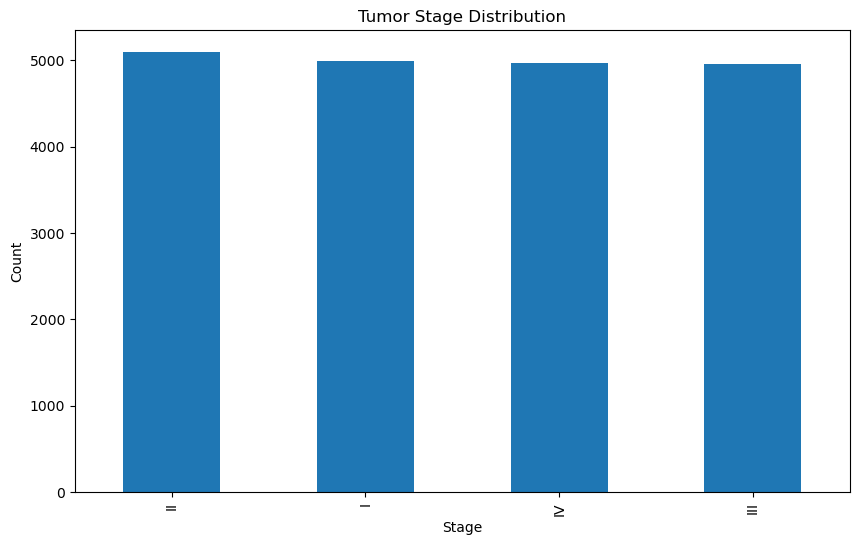

In [138]:
plt.figure(figsize=(10,6))
df["Stage"].value_counts().plot(kind="bar")
plt.title("Tumor Stage Distribution")
plt.xlabel("Stage")
plt.ylabel("Count")
plt.show()

In [139]:
df["Symptom_1"].value_counts()
df["Symptom_1"].value_counts(normalize=True)*100

Symptom_1
Headache         25.225
Seizures         25.140
Nausea           24.845
Vision Issues    24.790
Name: proportion, dtype: float64

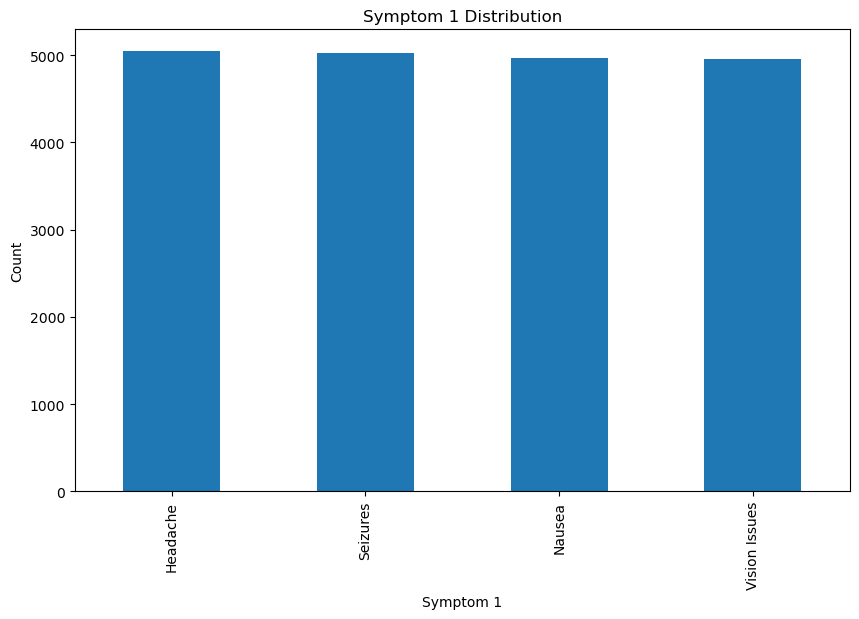

In [140]:
plt.figure(figsize=(10,6))
df["Symptom_1"].value_counts().plot(kind="bar")
plt.title("Symptom 1 Distribution")
plt.xlabel("Symptom 1")
plt.ylabel("Count")
plt.show()

In [141]:
df["Symptom_2"].value_counts()
df["Symptom_2"].value_counts(normalize=True)*100

Symptom_2
Seizures         25.270
Vision Issues    25.095
Headache         24.980
Nausea           24.655
Name: proportion, dtype: float64

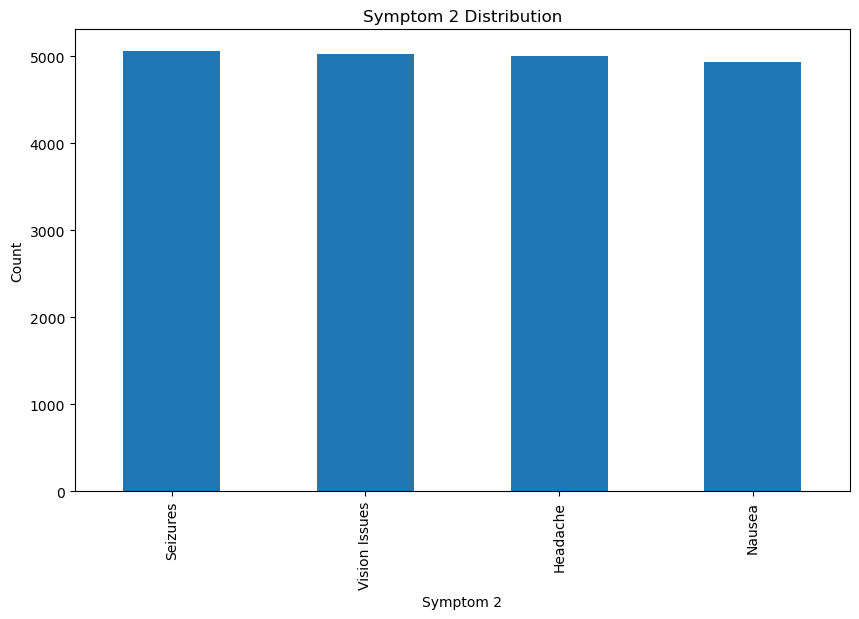

In [142]:
plt.figure(figsize=(10,6))
df["Symptom_2"].value_counts().plot(kind="bar")
plt.title("Symptom 2 Distribution")
plt.xlabel("Symptom 2")
plt.ylabel("Count")
plt.show()

## Conteo de valores pacientes

In [143]:
c_pat = ((df["Chemotherapy"] == "Yes") & (df["Radiation_Treatment"] == "Yes") & (df["Surgery_Performed"] == "Yes")).sum()
c_pat

np.int64(2590)

In [144]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Tumor_Type', 'Tumor_Size', 'Location',
       'Histology', 'Stage', 'Symptom_1', 'Symptom_2', 'Symptom_3',
       'Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy',
       'Survival_Rate', 'Tumor_Growth_Rate', 'Family_History', 'MRI_Result',
       'Follow_Up_Required'],
      dtype='object')

## Regresion y, X 

In [145]:
y = df["Tumor_Type"]
X = df.drop(columns=["Patient_ID", "Tumor_Size"])

In [146]:
numerical = ["Age", "Tumor_Size"]
categorical = ["Gender", "Tumor_Type", "Location", "Histology", "Stage", "Symptom_1", "Symptom_2"]
numerical_pipeline = Pipeline([
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical),
    ("cat", categorical_pipeline, categorical)
])


In [147]:
y = df["Tumor_Type"].map({"Benign": 0, "Malignant": 1})
X = df[numerical + categorical]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("y distribution:\n", y.value_counts())
print("X shape:", X.shape)

y distribution:
 Tumor_Type
1    10030
0     9970
Name: count, dtype: int64
X shape: (20000, 9)


In [148]:
y = df["Tumor_Type"]
X = df.drop(columns=["Patient_ID", "Tumor_Size"])

In [149]:
X_train_star = X_train.drop(columns=["Tumor_Type"]).copy()
X_test_star = X_test.drop(columns=["Tumor_Type"]).copy()

for df_ in (X_train_star, X_test_star):
    df_["Age_Tumor_interaction"] = df_["Age"] * df_["Tumor_Size"]
    df_["Tumor_Size_sq"] = df_["Tumor_Size"] ** 2
    df_["symptom_match"] = (df_["Symptom_1"] == df_["Symptom_2"]).astype(int)

numerical_star = ["Age", "Tumor_Size", "Age_Tumor_interaction", "Tumor_Size_sq"]
categorical_star = ["Gender", "Location", "Histology", "Stage", "Symptom_1", "Symptom_2"]

preprocessor_star = ColumnTransformer([
    ("num", StandardScaler(), numerical_star),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_star)
])

model_pipeline = Pipeline([
    ("preprocessor", preprocessor_star),
    ("clf", MLPClassifier(max_iter=300, random_state=42))
])

model_pipeline.fit(X_train_star, y_train)

y_pred = model_pipeline.predict(X_test_star)
correct_predictions = (y_pred == y_test).sum()

print("Correct predictions:", correct_predictions, "de", len(y_test))
print("Accuracy:", accuracy_score(y_test, y_pred))

Correct predictions: 2017 de 4000
Accuracy: 0.50425


c:\Users\Tadeo\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [150]:
from sklearn.preprocessing import OrdinalEncoder

In [151]:
numerical = ["Age", "Tumor_Size"]  # Only include columns that exist in the dataframe
categorical = ["Gender", "Chemotherapy", "Radiation_Treatment", "Family_History", "Surgery_Performed", "MRI_Result", "Follow_Up_Required"]

X = df.drop(columns=["Tumor_Type"])  # Ensure "Tumor_Type" is dropped
y = df["Tumor_Type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical),
        ("cat", OneHotEncoder(), categorical),
        ("label", OrdinalEncoder(), ["Stage"])
    ]
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42))
])
pipeline.fit(X, y)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Tumor_Size']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Gender', 'Chemotherapy',
                                                   'Radiation_Treatment',
                                                   'Family_History',
                                                   'Surgery_Performed',
                                                   'MRI_Result',
                                                   'Follow_Up_Required']),
                                                 ('label', OrdinalEncoder(),
                                                  ['Stage'])])),
                ('model', MLPClassifier(max_iter=300, random_state=42))])

In [152]:
F1 = classification_report(y_test, y_pred)
print(F1)

              precision    recall  f1-score   support

           0       0.50      0.51      0.51      1994
           1       0.51      0.50      0.50      2006

    accuracy                           0.50      4000
   macro avg       0.50      0.50      0.50      4000
weighted avg       0.50      0.50      0.50      4000



In [153]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.3f}")

F1 Score: 0.503
